# 13 · Visualization: Scatter Plots

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Explore relationships between age, experience, compensation, job satisfaction and language use.

**Data:** Stack Overflow Developer Survey (IBM Skills Network copy, 65,437 responses × 114 columns)

**Tools:** pandas, Matplotlib, Seaborn

### Key results
- Scatter and regression plots relating age, coding experience, compensation, job satisfaction and language popularity.

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 12](12_viz_box_plots.ipynb) · [Project README](../README.md) · [14 →](14_viz_bubble_plots.ipynb)

## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [5]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [6]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)


### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




**Approach:** `Age` ranges are mapped to their midpoints so that they can be plotted on a numeric axis.

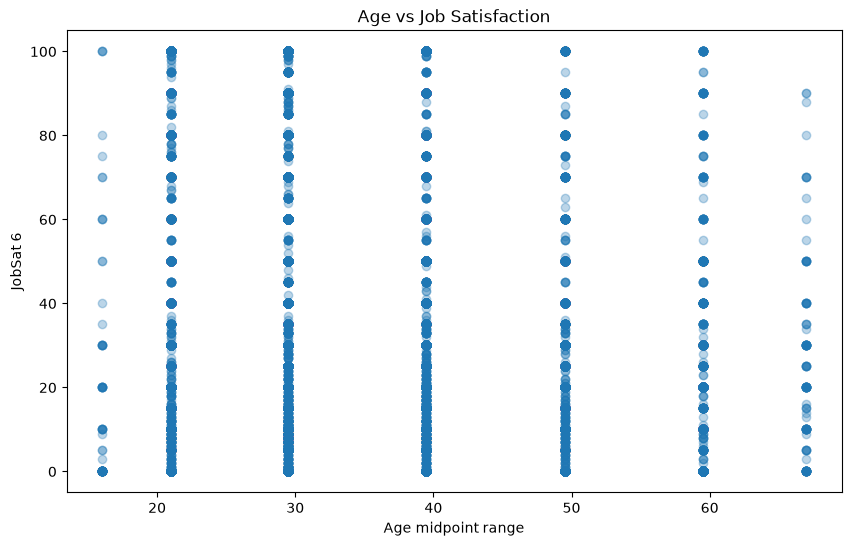

In [16]:
import numpy as np
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 67,
    'Prefer not to say': np.nan
}
df['AgeNum']=df['Age'].map(age_map)
df_scatter= df[['AgeNum', 'JobSatPoints_6']].dropna()

plt.figure(figsize=(10,6))
plt.scatter(x=df_scatter['AgeNum'], y=df_scatter['JobSatPoints_6'], alpha=0.3)
plt.title("Age vs Job Satisfaction")
plt.xlabel("Age midpoint range")
plt.ylabel("JobSat 6")

plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


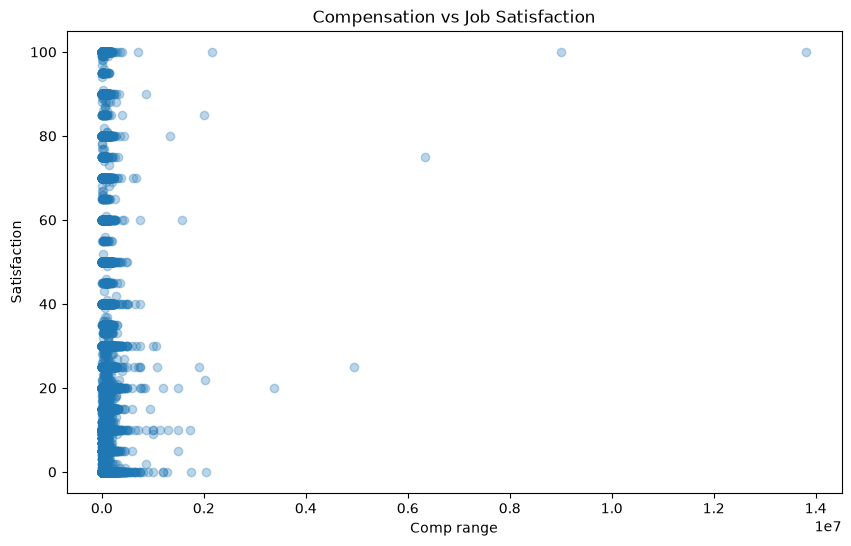

In [18]:
df_comp=df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()
plt.figure(figsize=(10, 6))
plt.scatter(x= df_comp['ConvertedCompYearly'], y= df_comp['JobSatPoints_6'], alpha=0.3)
plt.title("Compensation vs Job Satisfaction")
plt.xlabel("Comp range")
plt.ylabel("Satisfaction") 
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


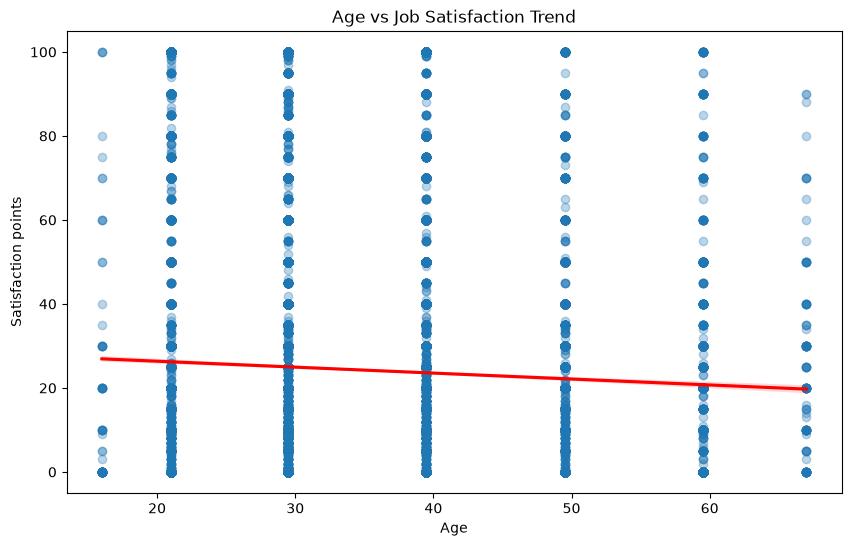

In [23]:
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(x='AgeNum', y='JobSatPoints_6', data= df_scatter, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Age vs Job Satisfaction Trend')
plt.xlabel('Age')
plt.ylabel('Satisfaction points') 
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


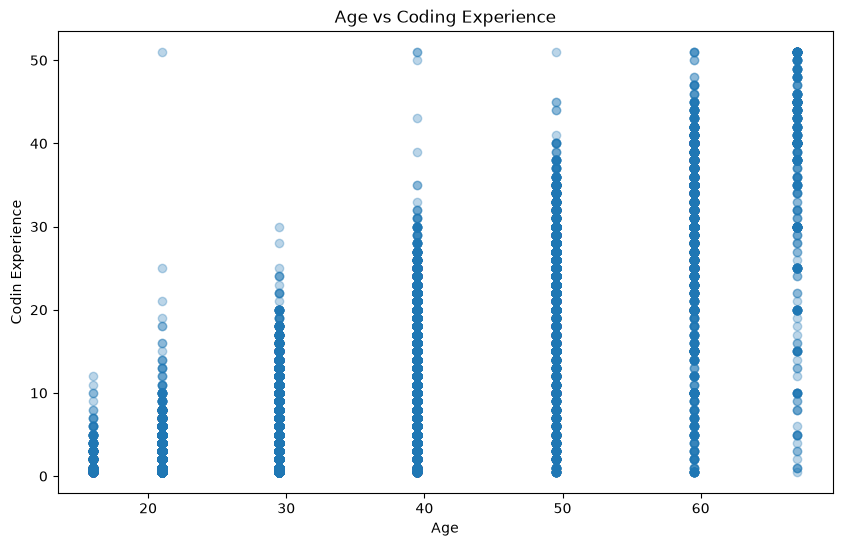

In [26]:
df['YearsCodeNum'] = pd.to_numeric(
    df['YearsCodePro'].replace({'Less than 1 year': 0.5, 'More than 50 years': 51}),
    errors='coerce'
)
df_years = df[['AgeNum', 'YearsCodeNum']].dropna()
plt.figure(figsize=(10, 6))
plt.scatter(x= df_years['AgeNum'], y=df_years['YearsCodeNum'], alpha=0.3)
plt.title("Age vs Coding Experience") 
plt.xlabel('Age') 
plt.ylabel('Coding Experience') 
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


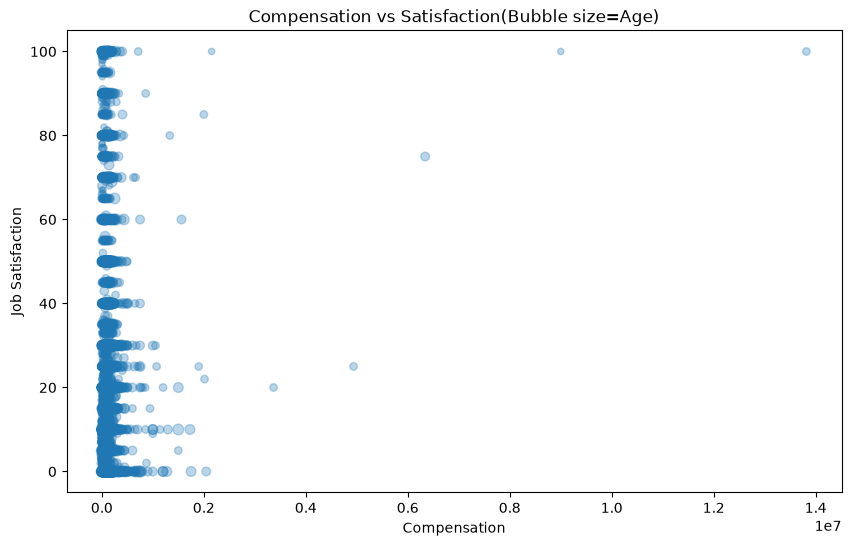

In [29]:
df_bubble= df[["ConvertedCompYearly", "JobSatPoints_6", "AgeNum"]].dropna()
plt.figure(figsize=(10,6))
plt.scatter(x=df_bubble['ConvertedCompYearly'], y=df_bubble['JobSatPoints_6'], s=df_bubble['AgeNum'], alpha=0.3) 
plt.title("Compensation vs Satisfaction(Bubble size=Age)")
plt.xlabel("Compensation") 
plt.ylabel("Job Satisfaction")
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


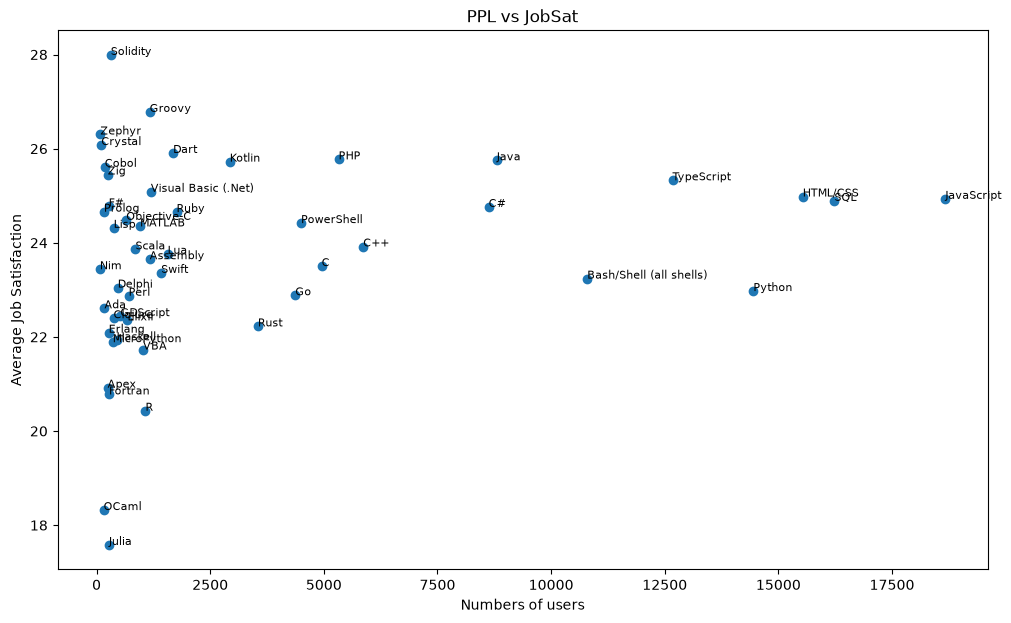

In [36]:
df_lang=df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_lang= df_lang.explode('LanguageHaveWorkedWith')

lang_stats = df_lang.groupby('LanguageHaveWorkedWith')['JobSatPoints_6'].agg(['count', 'mean'])
plt.figure(figsize=(12, 7))
plt.scatter(x =lang_stats['count'], y= lang_stats['mean']) 
for lang, row in lang_stats.iterrows():
    plt.text(row['count'], row['mean'], lang, fontsize=8) 
plt.title("PPL vs JobSat")
plt.xlabel('Numbers of users')
plt.ylabel('Average Job Satisfaction') 
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


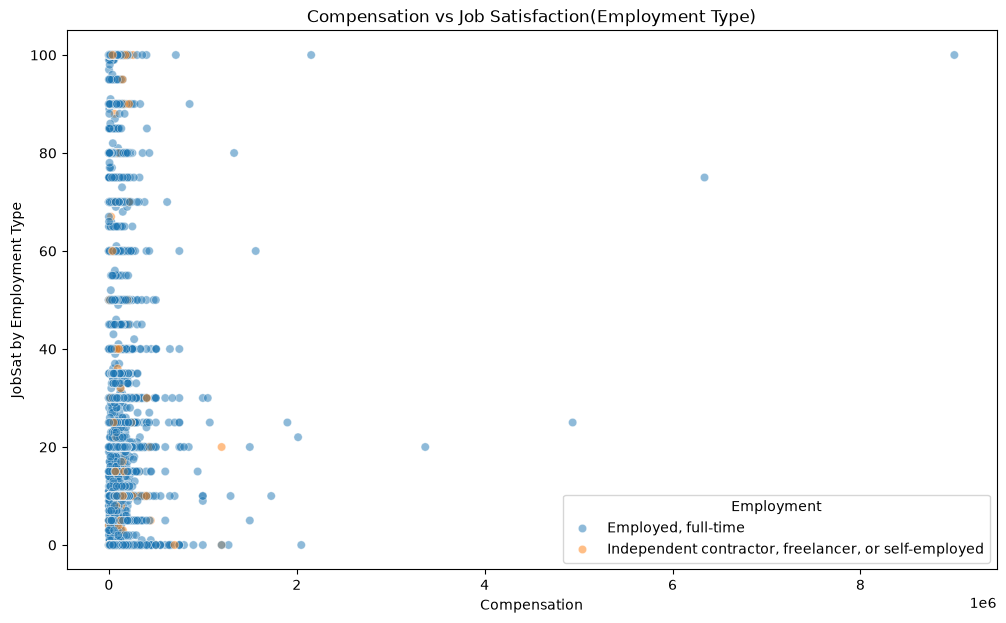

In [43]:
df_emp=df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna()
top_emp=df['Employment'].value_counts().head(3).index
df_emp= df_emp[df_emp['Employment'].isin(top_emp)]

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_emp, x= 'ConvertedCompYearly', y='JobSatPoints_6', hue='Employment', alpha=0.5) 
plt.title('Compensation vs Job Satisfaction(Employment Type)')
plt.xlabel('Compensation') 
plt.ylabel('JobSat by Employment Type')
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


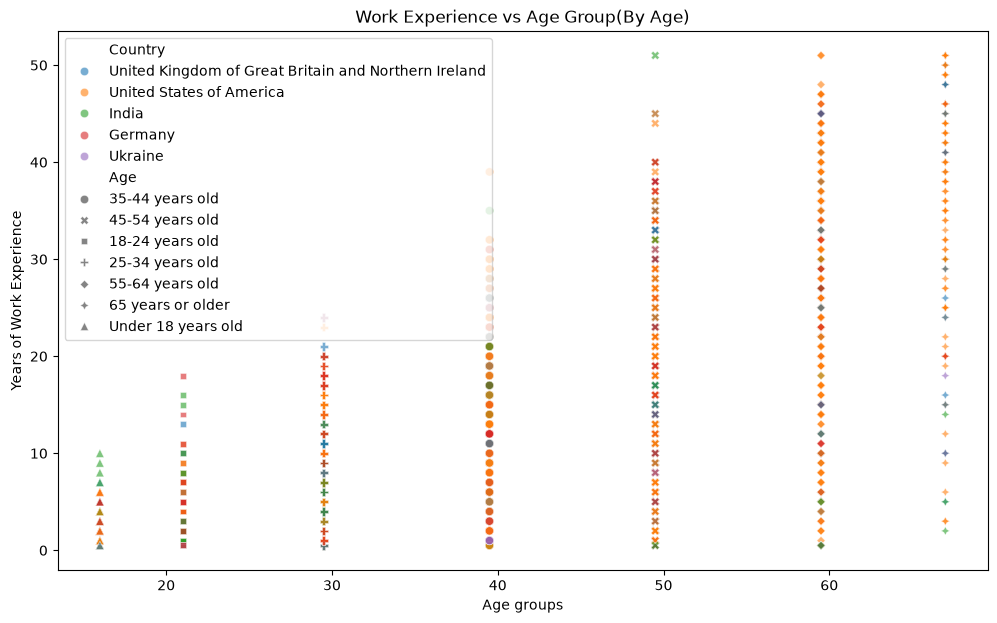

In [48]:
df_country= df[['YearsCodeNum', 'AgeNum', 'Age', 'Country']].dropna()
top_countries=df_country['Country'].value_counts().head(5).index
df_country= df_country[df_country['Country'].isin(top_countries)]
plt.figure(figsize=(12, 7)) 
sns.scatterplot(data= df_country, x= 'AgeNum', y='YearsCodeNum', hue='Country', style='Age', alpha=0.6)
plt.title('Work Experience vs Age Group(By Age)') 
plt.xlabel('Age groups') 
plt.ylabel('Years of Work Experience') 
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
